In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn


torch.autograd.set_detect_anomaly(True)
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
class PolicyNetwork(nn.Module):

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        super().__init__()

        hidden_space1 = 16
        hidden_space2 = 32

        self.policy_net = nn.Sequential(
            nn.Flatten(start_dim=0),
            nn.Linear(obs_space_dims, hidden_space1),
            nn.ReLU(),
            nn.Linear(hidden_space1, hidden_space2),
            nn.ReLU(),
            nn.Linear(hidden_space2, action_space_dims),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        logits = self.policy_net(x.float())
        logits[~mask] = torch.finfo().min

        return logits

In [3]:
class Reinforce:
    def __init__(self, obs_space_dims: int, action_space_dims: int):
        self.lr = 1e-4
        self.gamma = 0.99
        self.eps = 1e-6

        self.net = PolicyNetwork(obs_space_dims, action_space_dims)
        self.optim = torch.optim.AdamW(self.net.parameters(), lr=self.lr)

        self.log_probs = []
        self.rewards = []

    def sample_action(self, state: np.ndarray, mask: np.ndarray) -> float:
        state = torch.tensor(np.array(state))
        mask = torch.tensor(np.array(mask), dtype=bool)
        logits = self.net(state, mask)

        distrib = torch.distributions.categorical.Categorical(logits=logits)
        action = distrib.sample(sample_shape=torch.Size([1]))
        log_prob = distrib.log_prob(action)

        action = action.item()

        self.log_probs.append(log_prob)

        return int(action)

    def update(self):
        running_g = 0
        gs = []

        for r in self.rewards[::-1]:
            running_g = r + self.gamma * running_g
            gs.insert(0, running_g)
        
        deltas = torch.tensor(gs)

        loss = 0
        for log_prob, delta in zip(self.log_probs, deltas):
            loss += log_prob * delta * -1.0

        self.optim.zero_grad()
        loss.backward()
        self.optim.step()

        self.log_probs = []
        self.rewards = []

In [4]:
class RandomAgent:
    def sample_action(self, state: np.ndarray, mask: np.ndarray) -> float:
        return random.choice(np.where(mask)[0])

In [6]:
from fanorona_aec import fanorona_v1

env = fanorona_v1.env()

total_num_episodes = 1000
seeds = (1,) # (1, 2, 3, 5, 8)

rewards_over_seeds = {agent: [] for agent in env.possible_agents}

In [7]:
obs_space_dims = np.prod(env.observation_space(env.possible_agents[0])['observation'].shape)
action_space_dims = env.action_space(env.possible_agents[0]).n
policy = {'black': Reinforce(obs_space_dims, action_space_dims), 'white': RandomAgent()}
# policy['white'] = Reinforce(obs_space_dims, action_space_dims, policy['black'])
# log_probs = {agent: [] for agent in env.possible_agents}
# rewards = {agent: [] for agent in env.possible_agents}

In [8]:
for seed in seeds:
    print(f"Seed: {seed}")
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    rewards_over_episodes = {agent: [] for agent in env.possible_agents}

    for episode in range(total_num_episodes):
        env.reset(seed=seed)
        rewards_in_episode = {agent: [] for agent in env.possible_agents}
        for agent in env.agent_iter():
            obs, reward, terminated, truncated, info = env.last()
            action = policy[agent].sample_action(obs['observation'], obs['action_mask'])
            env.step(action)
            
            if agent == 'black':
                policy[agent].rewards.append(reward)
            rewards_in_episode[agent].append(reward)

        # receive last reward
        for agent in env.possible_agents:
            rewards_in_episode[agent].append(env.rewards[agent])
            if agent == 'black':
                policy[agent].rewards.append(reward)

        for agent in env.possible_agents:
            rewards_over_episodes[agent].append(rewards_in_episode[agent])
            if agent == 'black':
                policy[agent].update()

        if episode % 10 == 0:
            avg_reward = {agent: 0 for agent in env.possible_agents}
            for agent in env.possible_agents:
                avg_reward[agent] = np.mean([rewards_in_episode[agent][-1] for rewards_in_episode[agent] in rewards_over_episodes[agent][-10:]])
            print(f"Episode: {episode} Average Reward: {avg_reward}")

    for agent in env.possible_agents:
        # Avoid in-place append by creating a new list
        if agent in rewards_over_seeds:
            rewards_over_seeds[agent].append(rewards_over_episodes[agent])

Seed: 1
Episode: 0 Average Reward: {'black': -1.0, 'white': 1.0}
Episode: 10 Average Reward: {'black': -0.2, 'white': 0.2}
Episode: 20 Average Reward: {'black': 0.0, 'white': 0.0}
Episode: 30 Average Reward: {'black': 0.2, 'white': -0.2}
Episode: 40 Average Reward: {'black': -0.2, 'white': 0.2}
Episode: 50 Average Reward: {'black': -0.4, 'white': 0.4}
Episode: 60 Average Reward: {'black': -0.6, 'white': 0.6}
Episode: 70 Average Reward: {'black': 0.0, 'white': 0.0}
Episode: 80 Average Reward: {'black': 0.0, 'white': 0.0}
Episode: 90 Average Reward: {'black': 0.0, 'white': 0.0}
Episode: 100 Average Reward: {'black': 0.0, 'white': 0.0}
Episode: 110 Average Reward: {'black': -0.2, 'white': 0.2}
Episode: 120 Average Reward: {'black': 0.6, 'white': -0.6}
Episode: 130 Average Reward: {'black': 0.4, 'white': -0.4}
Episode: 140 Average Reward: {'black': 0.2, 'white': -0.2}
Episode: 150 Average Reward: {'black': -0.8, 'white': 0.8}
Episode: 160 Average Reward: {'black': -0.4, 'white': 0.4}
Episo

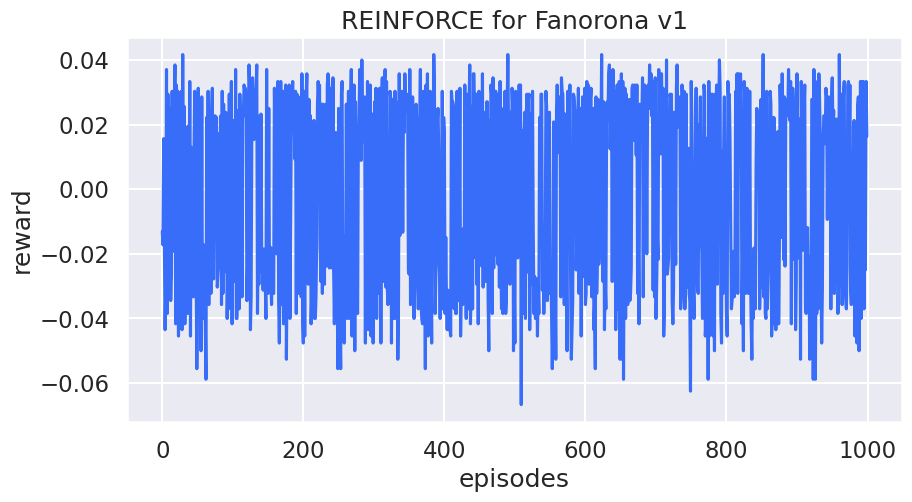

In [9]:
sns.set_theme(style="darkgrid", context="talk", palette="rainbow")
rewards_to_plot = {agent: [] for agent in env.possible_agents}
df = {agent: None for agent in env.possible_agents}
for agent in ['black']:
    rewards_to_plot[agent] = [[np.mean(reward) for reward in rewards_over_episodes[agent]] for rewards_over_episodes[agent] in rewards_over_seeds[agent]]
    df[agent] = pd.DataFrame(rewards_to_plot[agent]).melt()
    df[agent].rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
    sns.lineplot(x="episodes", y="reward", data=df[agent]).set(
        title="REINFORCE for Fanorona v1"
    )
plt.show()

In [10]:
wins = {agent: 0 for agent in env.possible_agents}
with torch.no_grad():
    for episode in range(total_num_episodes):
        env.reset(seed=seed)
        for agent in env.agent_iter():
            obs, reward, terminated, truncated, info = env.last()
            action = policy[agent].sample_action(obs['observation'], obs['action_mask'])
            env.step(action)

        if env.rewards['black'] > env.rewards['white']:
            wins['black'] += 1
            print(f"Game {episode}: Black wins: {wins['black']}")
        elif env.rewards['black'] < env.rewards['white']:
            wins['white'] += 1
            print(f"Game {episode}: White wins: {wins['white']}")
        else:
            print(f"Game {episode}: Draw")


Game 0: Black wins: 1
Game 1: White wins: 1
Game 2: Black wins: 2
Game 3: Black wins: 3
Game 4: Black wins: 4
Game 5: Black wins: 5
Game 6: White wins: 2
Game 7: Black wins: 6
Game 8: Black wins: 7
Game 9: Black wins: 8
Game 10: Black wins: 9
Game 11: Black wins: 10
Game 12: White wins: 3
Game 13: White wins: 4
Game 14: Black wins: 11
Game 15: Black wins: 12
Game 16: White wins: 5
Game 17: Black wins: 13
Game 18: White wins: 6
Game 19: White wins: 7
Game 20: White wins: 8
Game 21: White wins: 9
Game 22: White wins: 10
Game 23: White wins: 11
Game 24: White wins: 12
Game 25: White wins: 13
Game 26: White wins: 14
Game 27: White wins: 15
Game 28: Black wins: 14
Game 29: Black wins: 15
Game 30: White wins: 16
Game 31: White wins: 17
Game 32: White wins: 18
Game 33: White wins: 19
Game 34: White wins: 20
Game 35: Black wins: 16
Game 36: White wins: 21
Game 37: White wins: 22
Game 38: Black wins: 17
Game 39: Black wins: 18
Game 40: Black wins: 19
Game 41: Black wins: 20
Game 42: White wins:

In [11]:
print(wins)

{'black': 453, 'white': 547}


Wow, random agent does better than REINFORCE...